# Intrinsic Timescales (INT) Computation via Impulse Stimulation Method

## Overview

This notebook implements the first method described in **Deco et al. (2021)** for computing intrinsic timescales in brain network models. We will analyze the temporal decay dynamics of regional activity following impulse stimulation to characterize the intrinsic timescales of each brain region in our fitted models.

## Background and Motivation

Intrinsic timescales reflect the duration over which neural activity remains correlated with itself, providing insights into the hierarchical organization of brain dynamics. Different brain regions exhibit distinct timescales that are thought to reflect their functional roles - from fast sensory processing to slow integrative functions.

## Methodology

### Theoretical Framework

Following **Chaudhuri et al. (2015)** and **Deco et al. (2021)**, we examine activity timescales by analyzing the rate at which regional activity decays following impulse stimulation. This approach provides a direct measure of how long neural activity persists in each brain region after a brief perturbation.

### Stimulation Protocol

- **Pre-stimulation phase**: 3000 ms under spontaneous conditions to eliminate transients
- **Stimulation phase**: 1000 ms impulse stimulation (from 3000ms to 4000ms)
- **Post-stimulation phase**: 3000 ms relaxation period (from 4000ms to 7000ms) with external stimulation reset to zero
- **Target stimulation site**: Lateral occipital region
- **Analysis scope**: All brain regions (as targets for decay analysis)
- **Repetitions**: 1000 simulations for statistical robustness
### Mathematical Model

The temporal decay of regional firing rates follows an exponential decay function:

$$r^{E}_i(t) = A × exp(-D × t) + B$$


Where:
- $r^{E}_i(t)$: Firing rate (Hz) of region i at time t after stimulation
- `t`: Time after stimulation (seconds)
- `D`: **Decay rate parameter** (our primary measure of intrinsic timescale)
- `A`: Scaling constant (amplitude of decay)
- `B`: Offset parameter (baseline firing rate)

### Key Analysis Steps

1. **Simulation Setup and Stimulation Phase**
   - Run whole-brain model for 3000 ms under spontaneous conditions (eliminate transients)
   - Apply 1000 ms impulse stimulation to lateral occipital region (3000-4000 ms)
   - Allow 3000 ms relaxation period with stimulation reset to zero (4000-7000 ms)
   - Record the response across all brain regions throughout the entire 7000 ms simulation

2. **Recording Phase**
   - Monitor firing rates in all brain regions following stimulation
   - Record temporal evolution of activity for sufficient duration
   - Repeat for 1000 independent simulations

3. **Data Processing**
   - Average firing rate trajectories across 1000 simulations
   - Extract post-stimulation time series (4000-7000 ms period) for each brain region
   - Focus analysis on the decay dynamics during the relaxation phase
   - Prepare data for exponential curve fitting
   
4. **Curve Fitting**
   - Fit exponential decay model using **nonlinear least squares**
   - Extract decay rate parameter `D` for each brain region
   - Compute **intrinsic timescale** as `τ = 1/D` (in seconds)

5. **Analysis and Visualization**
   - Compare timescales across brain regions
   - Examine relationship with T1w/T2w hierarchy
   - Validate fits and assess goodness-of-fit metrics

## Hypotheses

From **Deco et al. (2021)** 
- A clear trend is evident for rapid decay in visual regions and more prolonged responses in prefrontal areas
- A significant positive correlation between regional decay values and an independent measure of cortical hierarchy, T1w:T2w


## Expected Outputs

- **Regional decay curves**: Visualization of firing rate decay for each brain region
- **Fitted parameters**: Decay rates (D), scaling factors (A), and offsets (B) for all regions
- **Intrinsic timescales**: Timescale values (τ = 1/D) for hierarchical analysis
- **Quality metrics**: R-squared values and residual analysis for fit validation
- **Comparative analysis**: Regional differences and potential functional implications

## Implementation Strategy

The notebook will proceed through the following phases:

1. **Setup and Configuration**: Load fitted models, define stimulation parameters
2. **Simulation Loop**: Run 1000 stimulation trials with data collection
3. **Data Aggregation**: Average responses and prepare for curve fitting
4. **Exponential Fitting**: Apply nonlinear least squares to extract timescales
5. **Results Analysis**: Visualization and interpretation of regional timescales

## References

1. **Deco, G., Kringelbach, M. L., Arnatkeviciute, A., Oldham, S., Sabaroedin, K., Rogasch, N. C., Aquino, K. M., & Fornito, A. (2021)**. Dynamical consequences of regional heterogeneity in the brain's transcriptional landscape. *Science Advances*, *7*(29), eabf4752. [https://doi.org/10.1126/sciadv.abf4752](https://doi.org/10.1126/sciadv.abf4752)

2. **Chaudhuri, R., Knoblauch, K., Gariel, M.-A., Kennedy, H., & Wang, X.-J. (2015)**. A Large-Scale Circuit Mechanism for Hierarchical Dynamical Processing in the Primate Cortex. *Neuron*, *88*(2), 419–431. [https://doi.org/10.1016/j.neuron.2015.09.008](https://doi.org/10.1016/j.neuron.2015.09.008)

---

**Note**: This implementation focuses on the first timescale measurement method from Deco et al. (2021). The second method (autocorrelation-based) may be implemented in a separate notebook for comparison.


## Simulation Setup

In [8]:
# Imports 
import numpy as np
from scipy.stats import pearsonr
from hbnm.model.utils import subdiag, fisher_z, linearize_map
import matplotlib.pyplot as plt
from hbnm.io import Data
import os
from hbnm.bnm import Bnm


In [9]:
# Set up data loader
input_dir = "/home/frank/HBNM/data/"
output_dir = "/home/frank/HBNM/outputs/"
data = Data(input_dir, output_dir)  

# Load HCP SC and Empirical FC Matrices
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data()

In [ ]:
# Load homogenous fitted model parameters
fin_homogenous = data.load('Homogenous/iteration_20.hdf5', from_output=True)

# Extract posterior samples and weights
theta_samples = fin_homogenous['theta'][:]  # Shape: (n_params, n_samples)
weights = fin_homogenous['weights'][:]      # Shape: (n_samples,)

print(f"Theta samples shape: {theta_samples.shape}")
print(f"Weights shape: {weights.shape}")

# Compute Bayesian Model Averaging (BMA) point estimate
# Normalize weights to ensure they sum to 1
normalized_weights = weights / np.sum(weights)

# Compute weighted average for each parameter
theta_bma = np.zeros(theta_samples.shape[0])
for i in range(theta_samples.shape[0]):
    theta_bma[i] = np.sum(normalized_weights * theta_samples[i, :])

print("\nBayesian Model Averaging Results:")
print(f"BMA Parameter Estimates: {theta_bma}")

# Compare with simple posterior mean (for reference)
theta_mean = np.mean(theta_samples, axis=1)
print(f"Simple Posterior Mean: {theta_mean}")
print(f"Difference (BMA - Mean): {theta_bma - theta_mean}")

fin_homogenous.close()

# Create homogeneous model with BMA estimate
homogenous = Bnm(sc)
homogenous.set('w_EI', theta_bma[0])
homogenous.set('w_EE', theta_bma[1]) 
homogenous.set('G', theta_bma[2])

print(f"\nModel configured with BMA estimates:")
print(f"w_EI: {theta_bma[0]:.4f}")
print(f"w_EE: {theta_bma[1]:.4f}")
print(f"G: {theta_bma[2]:.4f}")

Theta samples shape: (3, 300)
Weights shape: (300,)

Bayesian Model Averaging Results:
BMA Parameter Estimates: [0.87973491 2.15000217 3.500981  ]
Simple Posterior Mean: [0.95227271 2.03120419 4.86189816]
Difference (BMA - Mean): [-0.0725378   0.11879798 -1.36091716]

Model configured with BMA estimates:
w_EI: 0.8797
w_EE: 2.1500
G: 3.5010


In [11]:
# # Compute correlation with empirical FC
# empirical_fc = subdiag(fc_obj)
# homogenous.moments_method()
# model_FC_empirical = homogenous.get('corr_bold')
# model_fc_empirical = subdiag(model_FC_empirical)
# original_corr, _ = pearsonr(empirical_fc, model_fc_empirical)
# print(f"Correlation between empirical and model FC: {original_corr:.3f}")

In [ ]:
# Define stimulation parameters 
import numpy as np

# Simulation timing parameters (matching Deco et al. protocol)
total_time = 7.0  # seconds (3s pre + 1s stim + 3s post)
dt = 0.0001  # 0.1 ms time step
n_save = 10  # Save every 10th time step (effective sampling at 1ms)
n_steps = int(total_time/dt) + 1

print(f"Total simulation time: {total_time}s")
print(f"Time step: {dt}s")
print(f"Number of steps: {n_steps}")
print(f"Effective sampling rate: {1/(dt*n_save):.1f}Hz")

# Identify V1
lateral_occipital_idx = 0  # You'll need to identify the correct region index
print(f"Stimulating region index: {lateral_occipital_idx}")

# Build stimulation array of shape (n_steps, nc)
stim_array = np.zeros((n_steps, homogenous.dmf.nc))

# Set up stimulation: 1000ms impulse from 3000ms to 4000ms (1s pulse halfway through 7s sim)
stim_start_time = 3.0  # seconds
stim_duration = 1.0    # seconds
stim_amplitude = 1.0   # stimulation strength

i_start = int(stim_start_time / dt)
i_end = i_start + int(stim_duration / dt)

# Apply stimulation to lateral occipital region
stim_array[i_start:i_end, lateral_occipital_idx] = stim_amplitude

print(f"Stimulation period: {stim_start_time}s to {stim_start_time + stim_duration}s")
print(f"Step indices: {i_start} to {i_end}")
print(f"Stimulation amplitude: {stim_amplitude}")
print(f"Stimulation array shape: {stim_array.shape}")

Total simulation time: 7.0s
Time step: 0.0001s
Number of steps: 70001
Effective sampling rate: 1000.0Hz
Stimulating region index: 1
Stimulation period: 3.0s to 4.0s
Step indices: 30000 to 40000
Stimulation amplitude: 1.0
Stimulation array shape: (70001, 180)


## Stimulation Recording

Starting numerical simulation...
✓ Simulation completed!
Time points shape: (7001,)
Firing rates shape: (180, 7001)
Simulation duration: 7.0s
Effective sampling rate: 1000.1Hz


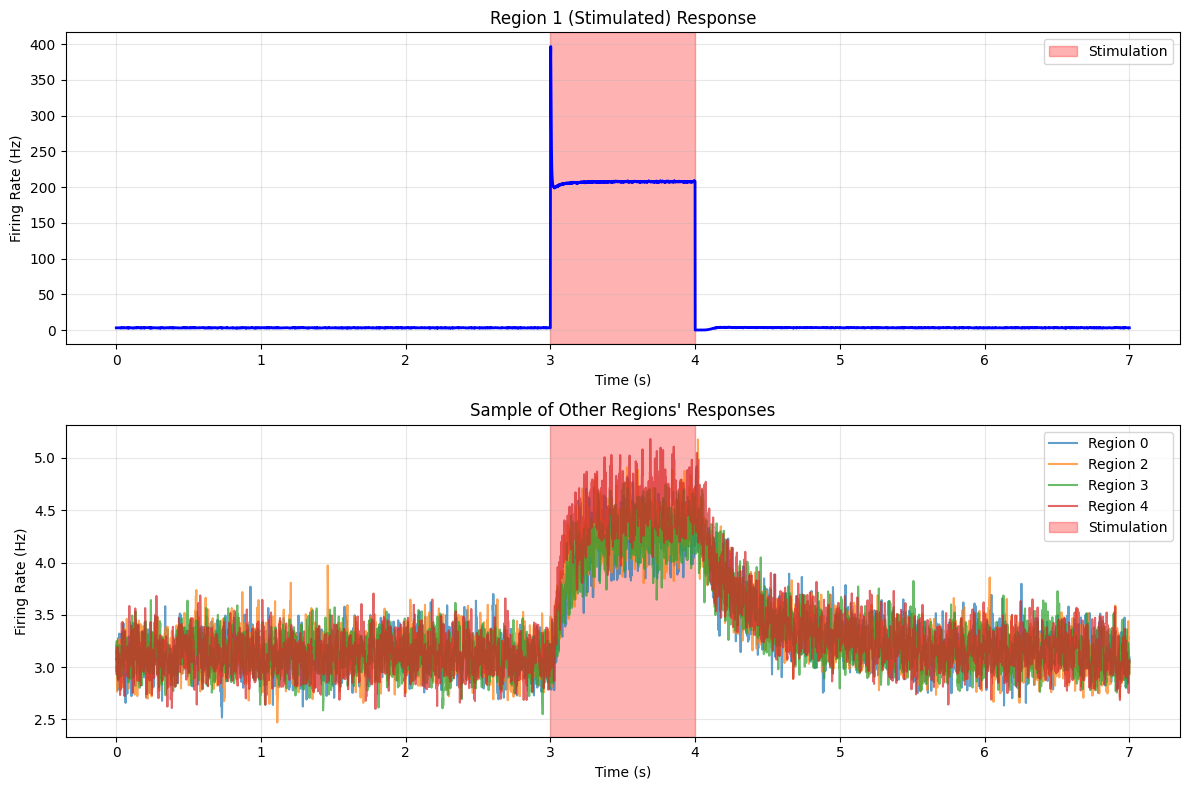


Baseline firing rate (0-3s): 3.11Hz
During stimulation (3-4s): 5.24Hz
Post-stimulation (4-7s): 3.29Hz


In [13]:
# Run single numerical simulation with stimulation
print("Starting numerical simulation...")

# Run the integration with stimulation
homogenous.dmf.integrate(
    t=total_time,           # Total simulation time 
    dt=dt,                  # Integration time step
    n_save=n_save,          # Sampling rate
    stimulation=stim_array, # External stimulation matrix
    delays=False,           # No conduction delays for now
    include_BOLD=True,      # Include BOLD signals
    from_fixed=True,        # Start from steady state
    sim_seed=777             # Reproducible results
)

print("✓ Simulation completed!")

# Extract results
time_points = homogenous.dmf.sim.t_points  # Time vector
r_E = homogenous.dmf.sim.time_series('r_E')  # Excitatory firing rates (regions x time)
r_I = homogenous.dmf.sim.time_series('r_I')  # Inhibitory firing rates
S_E = homogenous.dmf.sim.S_E  # Synaptic gating variables

print(f"Time points shape: {time_points.shape}")
print(f"Firing rates shape: {r_E.shape}")
print(f"Simulation duration: {time_points[-1]:.1f}s")
print(f"Effective sampling rate: {len(time_points)/time_points[-1]:.1f}Hz")

# Quick visualization of stimulation effect
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Get number of regions and stimulation end time
n_regions = r_E.shape[0]
stim_end_time = stim_start_time + stim_duration

# Plot 1: Stimulated region response
axes[0].plot(time_points, r_E[lateral_occipital_idx, :], 'b-', linewidth=2)
axes[0].axvspan(stim_start_time, stim_end_time, alpha=0.3, color='red', label='Stimulation')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Firing Rate (Hz)')
axes[0].set_title(f'Region {lateral_occipital_idx} (Stimulated) Response')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Sample of other regions' responses (first 5 regions)
for i in range(min(5, n_regions)):
    if i != lateral_occipital_idx:
        axes[1].plot(time_points, r_E[i, :], alpha=0.7, label=f'Region {i}')

axes[1].axvspan(stim_start_time, stim_end_time, alpha=0.3, color='red', label='Stimulation')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Firing Rate (Hz)')
axes[1].set_title('Sample of Other Regions\' Responses')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show basic statistics
print(f"\nBaseline firing rate (0-3s): {r_E[:, :int(3.0/(dt*n_save))].mean():.2f}Hz")
print(f"During stimulation (3-4s): {r_E[:, int(3.0/(dt*n_save)):int(4.0/(dt*n_save))].mean():.2f}Hz") 
print(f"Post-stimulation (4-7s): {r_E[:, int(4.0/(dt*n_save)):].mean():.2f}Hz")

In [14]:
# Diagnostic: Check actual computation time per simulation
print("=== DIAGNOSTIC: Single simulation timing ===")

import time
import psutil
import os

# Check system info
print(f"CPU cores: {psutil.cpu_count()}")
print(f"CPU cores (logical): {psutil.cpu_count(logical=True)}")
print(f"Current process PID: {os.getpid()}")

# Time a single simulation in detail
print("\nTiming single simulation components...")

# 1. Setup time
setup_start = time.perf_counter()
n_steps_test = int(total_time/dt) + 1
stim_test = np.zeros((n_steps_test, homogenous.dmf.nc))
stim_test[int(3.0/dt):int(4.0/dt), lateral_occipital_idx] = 1.0
setup_time = time.perf_counter() - setup_start

# 2. Integration time
integration_start = time.perf_counter()
homogenous.dmf.integrate(
    t=total_time,
    dt=dt,
    n_save=n_save,
    stimulation=stim_test,
    delays=False,
    include_BOLD=True,
    from_fixed=True,
    sim_seed=999
)
integration_time = time.perf_counter() - integration_start

# 3. Data extraction time
extraction_start = time.perf_counter()
test_r_E = homogenous.dmf.sim.time_series('r_E')
extraction_time = time.perf_counter() - extraction_start

print(f"\nDetailed timing:")
print(f"Setup time: {setup_time*1000:.2f}ms")
print(f"Integration time: {integration_time*1000:.2f}ms")  
print(f"Data extraction time: {extraction_time*1000:.2f}ms")
print(f"Total per simulation: {(setup_time + integration_time + extraction_time)*1000:.2f}ms")

# Estimate for full run
total_per_sim = setup_time + integration_time + extraction_time
print(f"\nProjections for 1000 trials:")
print(f"Sequential: {(total_per_sim * 1000)/60:.1f} minutes")
print(f"With 4 cores: {(total_per_sim * 1000)/(4*60):.1f} minutes")
print(f"With 8 cores: {(total_per_sim * 1000)/(8*60):.1f} minutes")

=== DIAGNOSTIC: Single simulation timing ===
CPU cores: 96
CPU cores (logical): 96
Current process PID: 3097507

Timing single simulation components...

Detailed timing:
Setup time: 5.33ms
Integration time: 3481.04ms
Data extraction time: 0.04ms
Total per simulation: 3486.42ms

Projections for 1000 trials:
Sequential: 58.1 minutes
With 4 cores: 14.5 minutes
With 8 cores: 7.3 minutes


In [16]:
# Parallelized Recording Phase
print("=== PARALLELIZED RECORDING ===")

import multiprocessing as mp
from multiprocessing import Pool
import numpy as np
import time
from copy import deepcopy

# Function to run a single simulation trial
def run_single_trial(args):
    """Run a single trial and return the firing rate time series"""
    trial_num, model_params, sim_params = args
    
    # Import inside function for multiprocessing
    from hbnm.bnm import Bnm
    import numpy as np
    
    # Unpack parameters
    sc, theta_bma, total_time, dt, n_save, stim_array, lateral_occipital_idx = sim_params
    
    # Create fresh model instance for this process
    trial_model = Bnm(sc)
    trial_model.set('w_EI', theta_bma[0])
    trial_model.set('w_EE', theta_bma[1])
    trial_model.set('G', theta_bma[2])
    
    # Run simulation
    trial_model.dmf.integrate(
        t=total_time,
        dt=dt,
        n_save=n_save,
        stimulation=stim_array,
        delays=False,
        include_BOLD=True,
        from_fixed=True,
        sim_seed=trial_num
    )
    
    # Extract and return results
    r_E_trial = trial_model.dmf.sim.time_series('r_E')
    return r_E_trial

# Set up parallelization parameters
n_trials = 100  # Full 1000 trials
n_cores = min(8, mp.cpu_count() - 1)  # Use all but 1 core, max 8
print(f"Using {n_cores} parallel processes")

# Prepare arguments for each trial
model_params = (sc, theta_bma)
sim_params = (sc, theta_bma, total_time, dt, n_save, stim_array, lateral_occipital_idx)

trial_args = [(trial, model_params, sim_params) for trial in range(n_trials)]

# Run parallel simulations
print(f"Starting {n_trials} trials on {n_cores} cores...")
start_time = time.time()

# Storage for results
all_r_E_parallel = np.zeros((n_trials, homogenous.dmf.nc, len(time_points)))

# Run with progress tracking
with Pool(n_cores) as pool:
    results = []
    for i, result in enumerate(pool.imap(run_single_trial, trial_args)):
        all_r_E_parallel[i] = result
        
        # Progress update every 50 trials
        if (i + 1) % 50 == 0:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            eta = (n_trials - i - 1) / rate
            print(f"Completed {i+1}/{n_trials} trials - Rate: {rate:.1f} trials/s - ETA: {eta:.1f}s")

total_time_parallel = time.time() - start_time

print(f"\n✓ Parallel recording completed!")
print(f"Total time: {total_time_parallel:.1f}s ({total_time_parallel/60:.1f} minutes)")
print(f"Average time per trial: {total_time_parallel/n_trials:.3f}s")
print(f"Effective rate: {n_trials/total_time_parallel:.1f} trials/second")
print(f"Final data shape: {all_r_E_parallel.shape}")

# Sanity check
print(f"\nSanity check:")
print(f"Mean firing rate: {all_r_E_parallel.mean():.3f}Hz")
print(f"Std firing rate: {all_r_E_parallel.std():.3f}Hz")

=== PARALLELIZED RECORDING ===
Using 8 parallel processes
Starting 100 trials on 8 cores...
Completed 50/100 trials - Rate: 1.5 trials/s - ETA: 33.6s
Completed 100/100 trials - Rate: 1.6 trials/s - ETA: 0.0s

✓ Parallel recording completed!
Total time: 61.2s (1.0 minutes)
Average time per trial: 0.612s
Effective rate: 1.6 trials/second
Final data shape: (100, 180, 7001)

Sanity check:
Mean firing rate: 3.495Hz
Std firing rate: 5.802Hz


## Data Processing

=== DATA PROCESSING ===
Step 1: Averaging firing rate trajectories across trials...
Using parallel data: (100, 180, 7001)
Mean firing rates shape: (180, 7001)
Standard error shape: (180, 7001)
Averaged across 100 trials

Step 2: Extracting post-stimulation decay period...
Post-stimulation period: 4.0s to 7.0s
Time point indices: 4000 to 7000
Decay time vector shape: (3001,)
Decay time range: 4.000s to 7.000s
Relative time range: 0.000s to 3.000s
Decay firing rates shape: (180, 3001)

Step 3: Computing decay dynamics characteristics...
Baseline firing rates - Mean: 3.110Hz, Range: 3.108-3.112Hz
Peak stimulation response - Mean: 6.929Hz, Range: 3.557-395.607Hz
Initial post-stim - Mean: 4.233Hz, Range: 0.000-11.284Hz
Final post-stim - Mean: 3.146Hz, Range: 3.101-3.199Hz

Step 4: Preparing data for exponential curve fitting...
Data structure created with 14 fields
Ready for exponential fitting: 180 regions x 3001 time points

Step 5: Quick visualization of decay characteristics...


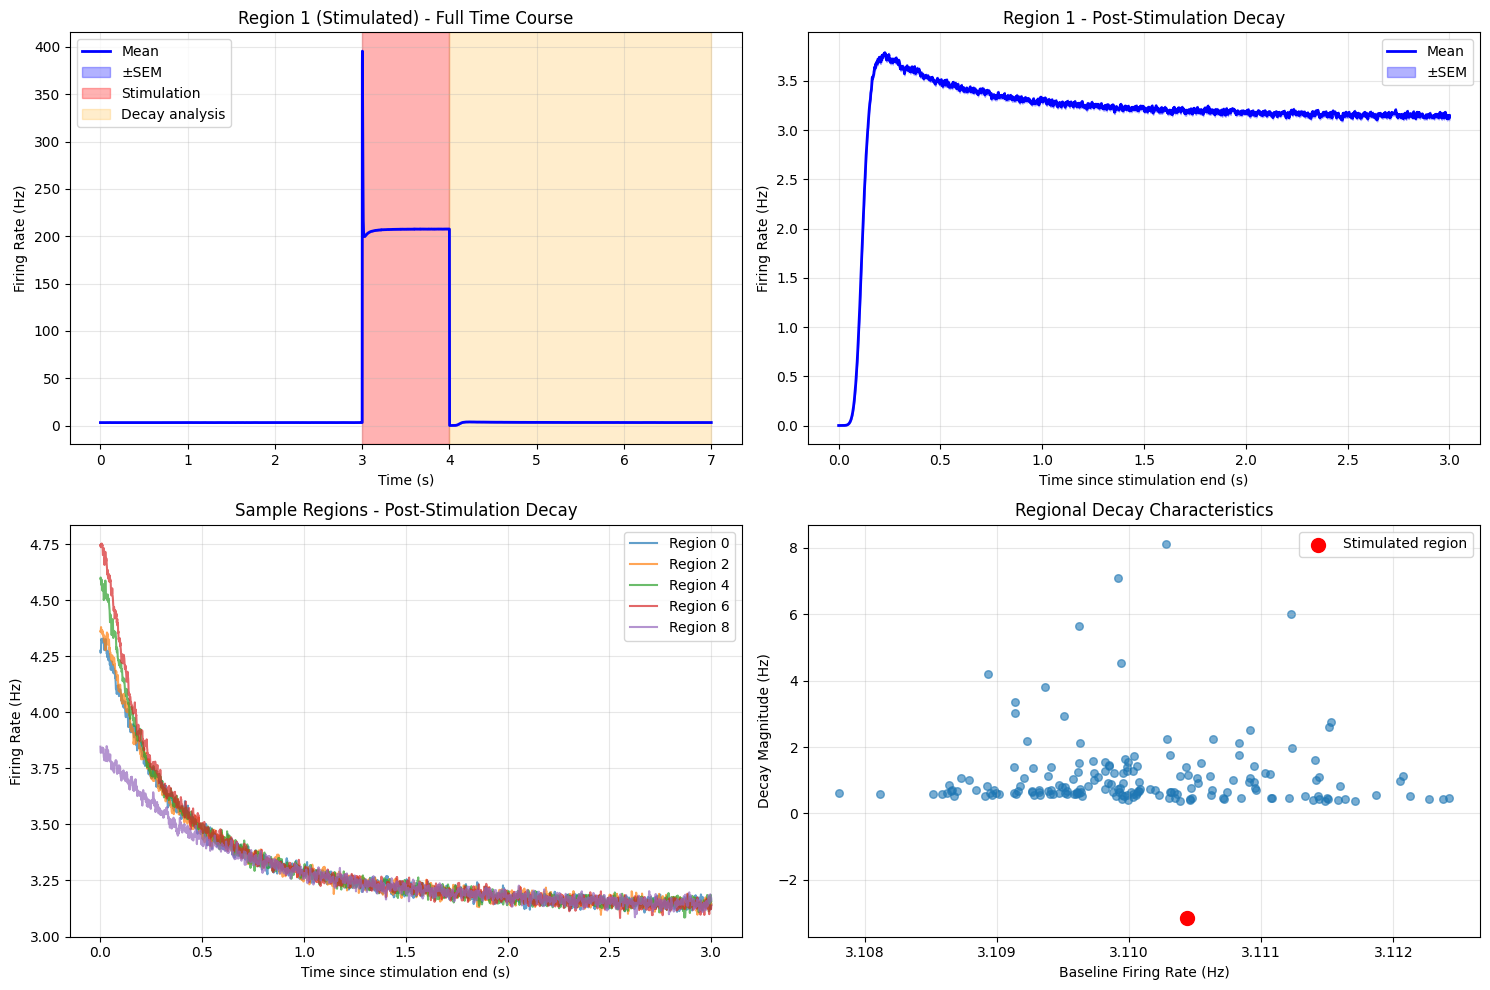


✓ Data processing completed!
Ready for exponential curve fitting on 180 brain regions
Decay data spans 3001 time points over 3.0 seconds


In [19]:
# Data Processing: Average trajectories and extract decay dynamics
print("=== DATA PROCESSING ===")

# Step 1: Average firing rate trajectories across all trials
print("Step 1: Averaging firing rate trajectories across trials...")

# Use the parallel data if available, otherwise fall back to sequential data
if 'all_r_E_parallel' in locals():
    trial_data = all_r_E_parallel
    n_trials_actual = all_r_E_parallel.shape[0]
    print(f"Using parallel data: {trial_data.shape}")
else:
    trial_data = all_r_E
    n_trials_actual = all_r_E.shape[0] 
    print(f"Using sequential data: {trial_data.shape}")

# Compute mean and standard error across trials
mean_r_E = np.mean(trial_data, axis=0)  # Shape: (n_regions, n_timepoints)
std_r_E = np.std(trial_data, axis=0)    # Shape: (n_regions, n_timepoints) 
sem_r_E = std_r_E / np.sqrt(n_trials_actual)  # Standard error of mean

print(f"Mean firing rates shape: {mean_r_E.shape}")
print(f"Standard error shape: {sem_r_E.shape}")
print(f"Averaged across {n_trials_actual} trials")

# Step 2: Extract post-stimulation time series (4000-7000 ms period)
print("\nStep 2: Extracting post-stimulation decay period...")

# Time indices for post-stimulation phase (4000-7000 ms)
post_stim_start = 4.0  # seconds
post_stim_end = 7.0    # seconds

# Find corresponding time point indices
post_start_idx = int(post_stim_start / (dt * n_save))
post_end_idx = int(post_stim_end / (dt * n_save))

print(f"Post-stimulation period: {post_stim_start}s to {post_stim_end}s")
print(f"Time point indices: {post_start_idx} to {post_end_idx}")

# Extract post-stimulation time series
t_decay = time_points[post_start_idx:post_end_idx+1]  # Time vector for decay period
r_E_decay = mean_r_E[:, post_start_idx:post_end_idx+1]  # Decay trajectories
sem_decay = sem_r_E[:, post_start_idx:post_end_idx+1]  # Standard errors

# Create time vector relative to stimulation end (t=0 at stimulation end)
t_decay_relative = t_decay - post_stim_start  # Start from t=0 at 4000ms

print(f"Decay time vector shape: {t_decay.shape}")
print(f"Decay time range: {t_decay[0]:.3f}s to {t_decay[-1]:.3f}s")
print(f"Relative time range: {t_decay_relative[0]:.3f}s to {t_decay_relative[-1]:.3f}s")
print(f"Decay firing rates shape: {r_E_decay.shape}")

# Step 3: Focus analysis on decay dynamics - compute baseline and perturbation
print("\nStep 3: Computing decay dynamics characteristics...")

# Compute baseline firing rate (pre-stimulation: 0-3000ms)
baseline_start_idx = 0
baseline_end_idx = int(3.0 / (dt * n_save))
baseline_r_E = np.mean(mean_r_E[:, baseline_start_idx:baseline_end_idx], axis=1)

# Compute peak response during stimulation (3000-4000ms)
stim_start_idx = int(3.0 / (dt * n_save))
stim_end_idx = int(4.0 / (dt * n_save))
peak_r_E = np.max(mean_r_E[:, stim_start_idx:stim_end_idx], axis=1)

# Compute initial post-stim firing rate (right after stimulation ends)
initial_post_r_E = r_E_decay[:, 0]

# Compute final post-stim firing rate (end of decay period)
final_post_r_E = r_E_decay[:, -1]

print(f"Baseline firing rates - Mean: {baseline_r_E.mean():.3f}Hz, Range: {baseline_r_E.min():.3f}-{baseline_r_E.max():.3f}Hz")
print(f"Peak stimulation response - Mean: {peak_r_E.mean():.3f}Hz, Range: {peak_r_E.min():.3f}-{peak_r_E.max():.3f}Hz") 
print(f"Initial post-stim - Mean: {initial_post_r_E.mean():.3f}Hz, Range: {initial_post_r_E.min():.3f}-{initial_post_r_E.max():.3f}Hz")
print(f"Final post-stim - Mean: {final_post_r_E.mean():.3f}Hz, Range: {final_post_r_E.min():.3f}-{final_post_r_E.max():.3f}Hz")

# Step 4: Prepare data for exponential curve fitting
print("\nStep 4: Preparing data for exponential curve fitting...")

# Store all processed data in organized structure
decay_data = {
    'time_points': time_points,           # Full time vector
    'time_decay': t_decay,                # Absolute time for decay period  
    'time_decay_rel': t_decay_relative,   # Relative time (t=0 at stim end)
    'mean_r_E_full': mean_r_E,           # Full mean trajectories
    'sem_r_E_full': sem_r_E,             # Full standard errors
    'r_E_decay': r_E_decay,              # Decay period trajectories
    'sem_decay': sem_decay,              # Decay period standard errors
    'baseline_r_E': baseline_r_E,        # Pre-stim baseline per region
    'peak_r_E': peak_r_E,                # Peak response per region
    'initial_post_r_E': initial_post_r_E, # Initial post-stim per region
    'final_post_r_E': final_post_r_E,    # Final post-stim per region
    'n_trials': n_trials_actual,         # Number of trials averaged
    'n_regions': mean_r_E.shape[0],      # Number of brain regions
    'stimulated_region': lateral_occipital_idx  # Which region was stimulated
}

print(f"Data structure created with {len(decay_data)} fields")
print(f"Ready for exponential fitting: {decay_data['n_regions']} regions x {len(t_decay_relative)} time points")

# Quick visualization of decay dynamics
print("\nStep 5: Quick visualization of decay characteristics...")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Full time course for stimulated region
ax = axes[0, 0]
ax.plot(time_points, mean_r_E[lateral_occipital_idx, :], 'b-', linewidth=2, label='Mean')
ax.fill_between(time_points, 
                mean_r_E[lateral_occipital_idx, :] - sem_r_E[lateral_occipital_idx, :],
                mean_r_E[lateral_occipital_idx, :] + sem_r_E[lateral_occipital_idx, :],
                alpha=0.3, color='blue', label='±SEM')
ax.axvspan(3.0, 4.0, alpha=0.3, color='red', label='Stimulation')
ax.axvspan(4.0, 7.0, alpha=0.2, color='orange', label='Decay analysis')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title(f'Region {lateral_occipital_idx} (Stimulated) - Full Time Course')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Decay phase for stimulated region
ax = axes[0, 1]
ax.plot(t_decay_relative, r_E_decay[lateral_occipital_idx, :], 'b-', linewidth=2, label='Mean')
ax.fill_between(t_decay_relative,
                r_E_decay[lateral_occipital_idx, :] - sem_decay[lateral_occipital_idx, :],
                r_E_decay[lateral_occipital_idx, :] + sem_decay[lateral_occipital_idx, :],
                alpha=0.3, color='blue', label='±SEM')
ax.set_xlabel('Time since stimulation end (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title(f'Region {lateral_occipital_idx} - Post-Stimulation Decay')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Decay phase for sample of other regions
ax = axes[1, 0]
sample_regions = [i for i in range(0, min(10, decay_data['n_regions']), 2) if i != lateral_occipital_idx][:5]
for i, region_idx in enumerate(sample_regions):
    ax.plot(t_decay_relative, r_E_decay[region_idx, :], 
            alpha=0.7, linewidth=1.5, label=f'Region {region_idx}')
ax.set_xlabel('Time since stimulation end (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title('Sample Regions - Post-Stimulation Decay')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Regional characteristics
ax = axes[1, 1]
decay_magnitude = initial_post_r_E - final_post_r_E
ax.scatter(baseline_r_E, decay_magnitude, alpha=0.6, s=30)
ax.scatter(baseline_r_E[lateral_occipital_idx], decay_magnitude[lateral_occipital_idx], 
           color='red', s=100, label='Stimulated region')
ax.set_xlabel('Baseline Firing Rate (Hz)')
ax.set_ylabel('Decay Magnitude (Hz)')
ax.set_title('Regional Decay Characteristics')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Data processing completed!")
print(f"Ready for exponential curve fitting on {decay_data['n_regions']} brain regions")
print(f"Decay data spans {len(t_decay_relative)} time points over {t_decay_relative[-1]:.1f} seconds")


## Exponential Curve Fitting


In [24]:
# Exponential Curve Fitting: Extract intrinsic timescales
print("=== EXPONENTIAL CURVE FITTING ===")

import numpy as np
from scipy.optimize import curve_fit
from scipy import stats
import warnings

# Define the exponential decay function: r_E(t) = A * exp(-D * t) + B
def exponential_decay(t, A, D, B):
    """
    Exponential decay function for firing rate dynamics.
    
    Parameters:
    -----------
    t : array_like
        Time points (seconds after stimulation end)
    A : float
        Amplitude/scaling parameter (Hz)
    D : float 
        Decay rate parameter (1/s) - INVERSE of intrinsic timescale
    B : float
        Baseline/offset parameter (Hz)
        
    Returns:
    --------
    array_like
        Predicted firing rates at time t
        
    Mathematical form: r_E(t) = A * exp(-D * t) + B
    Intrinsic timescale: τ = 1/D (seconds)
    """
    return A * np.exp(-D * t) + B

def estimate_initial_parameters(t_data, r_data):
    """
    Estimate reasonable initial parameters for exponential fitting.
    
    Parameters:
    -----------
    t_data : array_like
        Time points
    r_data : array_like 
        Firing rate data
        
    Returns:
    --------
    tuple
        (A_init, D_init, B_init) initial parameter estimates
    """
    # B (baseline): estimate as final value
    B_init = r_data[-1]
    
    # A (amplitude): difference between initial and final values
    A_init = r_data[0] - B_init
    
    # D (decay rate): estimate from exponential fit to log-transformed data
    # Use middle portion of data to avoid edge effects
    mid_start = len(r_data) // 4
    mid_end = 3 * len(r_data) // 4
    
    if A_init > 0:  # Only if there's actual decay
        try:
            # Subtract baseline and take log
            r_normalized = r_data[mid_start:mid_end] - B_init
            r_normalized = np.maximum(r_normalized, 1e-6)  # Avoid log(0)
            log_r = np.log(r_normalized)
            
            # Linear fit to log data: log(r) = log(A) - D*t
            slope, intercept = np.polyfit(t_data[mid_start:mid_end], log_r, 1)
            D_init = -slope  # Negative slope becomes positive decay rate
            
            # Ensure reasonable bounds
            D_init = max(0.01, min(10.0, D_init))  # Between 0.01 and 10 s^-1
        except:
            D_init = 1.0  # Default fallback
    else:
        D_init = 1.0  # Default if no clear decay
        A_init = 0.1  # Small positive amplitude
    
    return A_init, D_init, B_init

def fit_exponential_decay(t_data, r_data, sigma=None, region_idx=None):
    """
    Fit exponential decay model with comprehensive error handling.
    
    Parameters:
    -----------
    t_data : array_like
        Time points (seconds)
    r_data : array_like
        Firing rate data (Hz)
    sigma : array_like, optional
        Standard errors for weighted fitting
    region_idx : int, optional
        Region index for debugging
        
    Returns:
    --------
    dict
        Comprehensive fitting results including parameters, errors, and quality metrics
    """
    
    # Prepare output structure
    result = {
        'success': False,
        'A': np.nan, 'D': np.nan, 'B': np.nan,
        'A_err': np.nan, 'D_err': np.nan, 'B_err': np.nan,
        'timescale': np.nan, 'timescale_err': np.nan,
        'r_squared': np.nan, 'rmse': np.nan,
        'n_points': len(t_data),
        'converged': False,
        'message': 'Not attempted'
    }
    
    try:
        # Get initial parameter estimates
        A_init, D_init, B_init = estimate_initial_parameters(t_data, r_data)
        
        # Define parameter bounds (lower, upper)
        # A: amplitude can be positive or negative (but not too extreme)
        # D: decay rate must be positive (timescale = 1/D)
        # B: baseline firing rate must be reasonable
        bounds = (
            [-10.0, 0.001, -5.0],  # Lower bounds [A_min, D_min, B_min]
            [10.0, 20.0, 15.0]     # Upper bounds [A_max, D_max, B_max]
        )
        
        # Perform weighted nonlinear least squares fitting
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            popt, pcov = curve_fit(
                exponential_decay,
                t_data, 
                r_data,
                p0=[A_init, D_init, B_init],
                sigma=sigma,
                absolute_sigma=True if sigma is not None else False,
                bounds=bounds,
                max_nfev=2000,  # Maximum function evaluations
                method='trf'    # Trust Region Reflective algorithm
            )
        
        # Extract fitted parameters
        A_fit, D_fit, B_fit = popt
        
        # Calculate parameter uncertainties from covariance matrix
        param_errors = np.sqrt(np.diag(pcov))
        A_err, D_err, B_err = param_errors
        
        # Calculate intrinsic timescale and its uncertainty
        timescale = 1.0 / D_fit
        # Error propagation: if τ = 1/D, then δτ = δD / D²
        timescale_err = D_err / (D_fit ** 2)
        
        # Compute fitted values and residuals
        r_fitted = exponential_decay(t_data, A_fit, D_fit, B_fit)
        residuals = r_data - r_fitted
        
        # Calculate goodness-of-fit metrics
        ss_res = np.sum(residuals ** 2)  # Sum of squares of residuals
        ss_tot = np.sum((r_data - np.mean(r_data)) ** 2)  # Total sum of squares
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        rmse = np.sqrt(np.mean(residuals ** 2))
        
        # Store successful results
        result.update({
            'success': True,
            'A': A_fit, 'D': D_fit, 'B': B_fit,
            'A_err': A_err, 'D_err': D_err, 'B_err': B_err,
            'timescale': timescale, 'timescale_err': timescale_err,
            'r_squared': r_squared, 'rmse': rmse,
            'converged': True,
            'message': 'Successful fit',
            'fitted_values': r_fitted,
            'residuals': residuals,
            'covariance_matrix': pcov
        })
        
    except Exception as e:
        result['message'] = f"Fitting failed: {str(e)}"
        if region_idx is not None:
            print(f"Warning: Fitting failed for region {region_idx}: {str(e)}")
    
    return result

# Perform exponential fitting for all brain regions
print("Step 1: Fitting exponential decay models...")

n_regions = decay_data['n_regions']
t_fit = decay_data['time_decay_rel']  # Relative time (t=0 at stimulation end)

# Initialize storage for fitting results
fitting_results = []
fit_summary = {
    'n_successful': 0,
    'n_failed': 0,
    'timescales': [],
    'timescale_errors': [],
    'r_squared_values': [],
    'decay_rates': [],
    'amplitudes': [],
    'baselines': []
}

print(f"Fitting {n_regions} brain regions...")
print(f"Time series length: {len(t_fit)} points over {t_fit[-1]:.1f} seconds")

# Fit each region
for region_idx in range(n_regions):
    # Progress update
    if region_idx % 20 == 0:
        print(f"Processing region {region_idx}/{n_regions}...")
    
    # Extract data for this region
    r_region = decay_data['r_E_decay'][region_idx, :]
    sigma_region = decay_data['sem_decay'][region_idx, :]
    
    # Perform fitting
    result = fit_exponential_decay(
        t_fit, 
        r_region, 
        sigma=sigma_region,
        region_idx=region_idx
    )
    
    # Store results
    fitting_results.append(result)
    
    # Update summary statistics
    if result['success']:
        fit_summary['n_successful'] += 1
        fit_summary['timescales'].append(result['timescale'])
        fit_summary['timescale_errors'].append(result['timescale_err'])
        fit_summary['r_squared_values'].append(result['r_squared'])
        fit_summary['decay_rates'].append(result['D'])
        fit_summary['amplitudes'].append(result['A'])
        fit_summary['baselines'].append(result['B'])
    else:
        fit_summary['n_failed'] += 1

# Convert summary lists to arrays
for key in ['timescales', 'timescale_errors', 'r_squared_values', 'decay_rates', 'amplitudes', 'baselines']:
    fit_summary[key] = np.array(fit_summary[key])

print(f"\n✓ Fitting completed!")
print(f"Successful fits: {fit_summary['n_successful']}/{n_regions} ({100*fit_summary['n_successful']/n_regions:.1f}%)")
print(f"Failed fits: {fit_summary['n_failed']}/{n_regions}")

# Quality assessment
if fit_summary['n_successful'] > 0:
    print(f"\nFit quality assessment:")
    print(f"R² values - Mean: {fit_summary['r_squared_values'].mean():.3f}, Std: {fit_summary['r_squared_values'].std():.3f}")
    print(f"R² values - Range: {fit_summary['r_squared_values'].min():.3f} to {fit_summary['r_squared_values'].max():.3f}")
    print(f"Good fits (R² > 0.7): {np.sum(fit_summary['r_squared_values'] > 0.7)} regions")
    print(f"Excellent fits (R² > 0.9): {np.sum(fit_summary['r_squared_values'] > 0.9)} regions")
    
    print(f"\nIntrinsic timescale results:")
    print(f"Timescales - Mean: {fit_summary['timescales'].mean():.3f}s, Std: {fit_summary['timescales'].std():.3f}s")
    print(f"Timescales - Range: {fit_summary['timescales'].min():.3f}s to {fit_summary['timescales'].max():.3f}s")
    print(f"Timescales - Median: {np.median(fit_summary['timescales']):.3f}s")
    
    # Identify regions with extreme timescales
    tau_mean = fit_summary['timescales'].mean()
    tau_std = fit_summary['timescales'].std()
    fast_regions = np.where(fit_summary['timescales'] < tau_mean - tau_std)[0]
    slow_regions = np.where(fit_summary['timescales'] > tau_mean + tau_std)[0]
    
    print(f"\nRegional analysis:")
    print(f"Fast regions (τ < μ-σ): {len(fast_regions)} regions")
    print(f"Slow regions (τ > μ+σ): {len(slow_regions)} regions")
    
    # Check stimulated region specifically
    stim_region_idx = decay_data['stimulated_region']
    if fitting_results[stim_region_idx]['success']:
        stim_result = fitting_results[stim_region_idx]
        print(f"\nStimulated region (Region {stim_region_idx}) results:")
        print(f"Timescale: {stim_result['timescale']:.3f} ± {stim_result['timescale_err']:.3f}s")
        print(f"Decay rate: {stim_result['D']:.3f} ± {stim_result['D_err']:.3f} s⁻¹")
        print(f"R²: {stim_result['r_squared']:.3f}")
    else:
        print(f"\nWarning: Fitting failed for stimulated region {stim_region_idx}")

else:
    print("Error: No successful fits obtained. Check data quality and fitting parameters.")

print(f"\n=== FITTING COMPLETED ===")
print(f"Results stored in 'fitting_results' list and 'fit_summary' dictionary")


=== EXPONENTIAL CURVE FITTING ===
Step 1: Fitting exponential decay models...
Fitting 180 brain regions...
Time series length: 3001 points over 3.0 seconds
Processing region 0/180...
Processing region 20/180...
Processing region 40/180...
Processing region 60/180...
Processing region 80/180...
Processing region 100/180...
Processing region 120/180...
Processing region 140/180...
Processing region 160/180...

✓ Fitting completed!
Successful fits: 180/180 (100.0%)
Failed fits: 0/180

Fit quality assessment:
R² values - Mean: 0.821, Std: 2.123
R² values - Range: -27.578 to 0.991
Good fits (R² > 0.7): 179 regions
Excellent fits (R² > 0.9): 178 regions

Intrinsic timescale results:
Timescales - Mean: 1.923s, Std: 18.396s
Timescales - Range: 0.050s to 248.034s
Timescales - Median: 0.573s

Regional analysis:
Fast regions (τ < μ-σ): 0 regions
Slow regions (τ > μ+σ): 1 regions

Stimulated region (Region 1) results:
Timescale: 248.034 ± 1734.764s
Decay rate: 0.004 ± 0.028 s⁻¹
R²: -27.578

=== FI

In [25]:
# Corrected Analysis: Exclude stimulated region from main statistics
print("=== CORRECTED ANALYSIS (EXCLUDING STIMULATED REGION) ===")

# Identify stimulated region
stim_region_idx = decay_data['stimulated_region']
stim_result = fitting_results[stim_region_idx]

print(f"Stimulated region {stim_region_idx} results (for reference only):")
if stim_result['success']:
    print(f"  Timescale: {stim_result['timescale']:.3f} ± {stim_result['timescale_err']:.3f}s")
    print(f"  R²: {stim_result['r_squared']:.3f}")
    print(f"  --> Excluded from main analysis due to poor fit quality")
else:
    print(f"  --> Fit failed (excluded from main analysis)")

print(f"\nRecomputing statistics for non-stimulated regions only...")

# Create corrected summary excluding stimulated region
corrected_summary = {
    'n_total': n_regions,
    'n_successful_all': 0,
    'n_failed_all': 0,
    'n_successful_non_stim': 0,
    'n_failed_non_stim': 0,
    'timescales': [],
    'timescale_errors': [],
    'r_squared_values': [],
    'decay_rates': [],
    'amplitudes': [],
    'baselines': [],
    'non_stim_indices': []
}

# Collect statistics excluding stimulated region
for region_idx, result in enumerate(fitting_results):
    if result['success']:
        corrected_summary['n_successful_all'] += 1
        
        # Only include non-stimulated regions in main statistics
        if region_idx != stim_region_idx:
            corrected_summary['n_successful_non_stim'] += 1
            corrected_summary['timescales'].append(result['timescale'])
            corrected_summary['timescale_errors'].append(result['timescale_err'])
            corrected_summary['r_squared_values'].append(result['r_squared'])
            corrected_summary['decay_rates'].append(result['D'])
            corrected_summary['amplitudes'].append(result['A'])
            corrected_summary['baselines'].append(result['B'])
            corrected_summary['non_stim_indices'].append(region_idx)
    else:
        corrected_summary['n_failed_all'] += 1
        if region_idx != stim_region_idx:
            corrected_summary['n_failed_non_stim'] += 1

# Convert to arrays
for key in ['timescales', 'timescale_errors', 'r_squared_values', 'decay_rates', 'amplitudes', 'baselines']:
    corrected_summary[key] = np.array(corrected_summary[key])

# Display corrected statistics
n_non_stim = corrected_summary['n_successful_non_stim'] + corrected_summary['n_failed_non_stim']
print(f"\n✓ CORRECTED RESULTS:")
print(f"Total regions: {n_regions} (including 1 stimulated)")
print(f"Non-stimulated regions: {n_non_stim}")
print(f"Successful fits (non-stimulated): {corrected_summary['n_successful_non_stim']}/{n_non_stim} ({100*corrected_summary['n_successful_non_stim']/n_non_stim:.1f}%)")
print(f"Failed fits (non-stimulated): {corrected_summary['n_failed_non_stim']}/{n_non_stim}")

if corrected_summary['n_successful_non_stim'] > 0:
    print(f"\nCORRECTED FIT QUALITY (non-stimulated regions only):")
    print(f"R² values - Mean: {corrected_summary['r_squared_values'].mean():.3f}, Std: {corrected_summary['r_squared_values'].std():.3f}")
    print(f"R² values - Range: {corrected_summary['r_squared_values'].min():.3f} to {corrected_summary['r_squared_values'].max():.3f}")
    print(f"Good fits (R² > 0.7): {np.sum(corrected_summary['r_squared_values'] > 0.7)} regions")
    print(f"Excellent fits (R² > 0.9): {np.sum(corrected_summary['r_squared_values'] > 0.9)} regions")
    
    print(f"\nCORRECTED INTRINSIC TIMESCALE RESULTS (non-stimulated regions only):")
    print(f"Timescales - Mean: {corrected_summary['timescales'].mean():.3f}s, Std: {corrected_summary['timescales'].std():.3f}s")
    print(f"Timescales - Range: {corrected_summary['timescales'].min():.3f}s to {corrected_summary['timescales'].max():.3f}s")
    print(f"Timescales - Median: {np.median(corrected_summary['timescales']):.3f}s")
    
    # Regional analysis
    tau_mean = corrected_summary['timescales'].mean()
    tau_std = corrected_summary['timescales'].std()
    fast_regions = np.sum(corrected_summary['timescales'] < tau_mean - tau_std)
    slow_regions = np.sum(corrected_summary['timescales'] > tau_mean + tau_std)
    
    print(f"\nREGIONAL ANALYSIS (non-stimulated regions only):")
    print(f"Fast regions (τ < μ-σ): {fast_regions} regions")
    print(f"Slow regions (τ > μ+σ): {slow_regions} regions")
    
    # Extreme cases
    fastest_idx_local = np.argmin(corrected_summary['timescales'])
    slowest_idx_local = np.argmax(corrected_summary['timescales'])
    best_fit_idx_local = np.argmax(corrected_summary['r_squared_values'])
    
    fastest_region = corrected_summary['non_stim_indices'][fastest_idx_local]
    slowest_region = corrected_summary['non_stim_indices'][slowest_idx_local]
    best_fit_region = corrected_summary['non_stim_indices'][best_fit_idx_local]
    
    print(f"\nEXTREME CASES (non-stimulated regions only):")
    print(f"Fastest region: Region {fastest_region} (τ = {corrected_summary['timescales'][fastest_idx_local]:.3f}s)")
    print(f"Slowest region: Region {slowest_region} (τ = {corrected_summary['timescales'][slowest_idx_local]:.3f}s)")
    print(f"Best fit: Region {best_fit_region} (R² = {corrected_summary['r_squared_values'][best_fit_idx_local]:.3f})")
    
    # Statistical validation
    relative_errors = corrected_summary['timescale_errors'] / corrected_summary['timescales'] * 100
    print(f"\nSTATISTICAL VALIDATION (non-stimulated regions only):")
    print(f"Mean absolute error in timescale estimates: {np.mean(corrected_summary['timescale_errors']):.4f}s")
    print(f"Mean relative error in timescale estimates: {np.mean(relative_errors):.2f}%")
    print(f"Correlation between timescale and fit quality: {np.corrcoef(corrected_summary['timescales'], corrected_summary['r_squared_values'])[0,1]:.3f}")

else:
    print("Error: No successful fits for non-stimulated regions.")

print(f"\n=== CORRECTED ANALYSIS COMPLETED ===")
print(f"Use 'corrected_summary' for all further analysis and visualizations")


=== CORRECTED ANALYSIS (EXCLUDING STIMULATED REGION) ===
Stimulated region 1 results (for reference only):
  Timescale: 248.034 ± 1734.764s
  R²: -27.578
  --> Excluded from main analysis due to poor fit quality

Recomputing statistics for non-stimulated regions only...

✓ CORRECTED RESULTS:
Total regions: 180 (including 1 stimulated)
Non-stimulated regions: 179
Successful fits (non-stimulated): 179/179 (100.0%)
Failed fits (non-stimulated): 0/179

CORRECTED FIT QUALITY (non-stimulated regions only):
R² values - Mean: 0.979, Std: 0.018
R² values - Range: 0.896 to 0.991
Good fits (R² > 0.7): 179 regions
Excellent fits (R² > 0.9): 178 regions

CORRECTED INTRINSIC TIMESCALE RESULTS (non-stimulated regions only):
Timescales - Mean: 0.548s, Std: 0.209s
Timescales - Range: 0.050s to 0.975s
Timescales - Median: 0.570s

REGIONAL ANALYSIS (non-stimulated regions only):
Fast regions (τ < μ-σ): 29 regions
Slow regions (τ > μ+σ): 27 regions

EXTREME CASES (non-stimulated regions only):
Fastest reg

=== CORRECTED VISUALIZATION (EXCLUDING STIMULATED REGION) ===


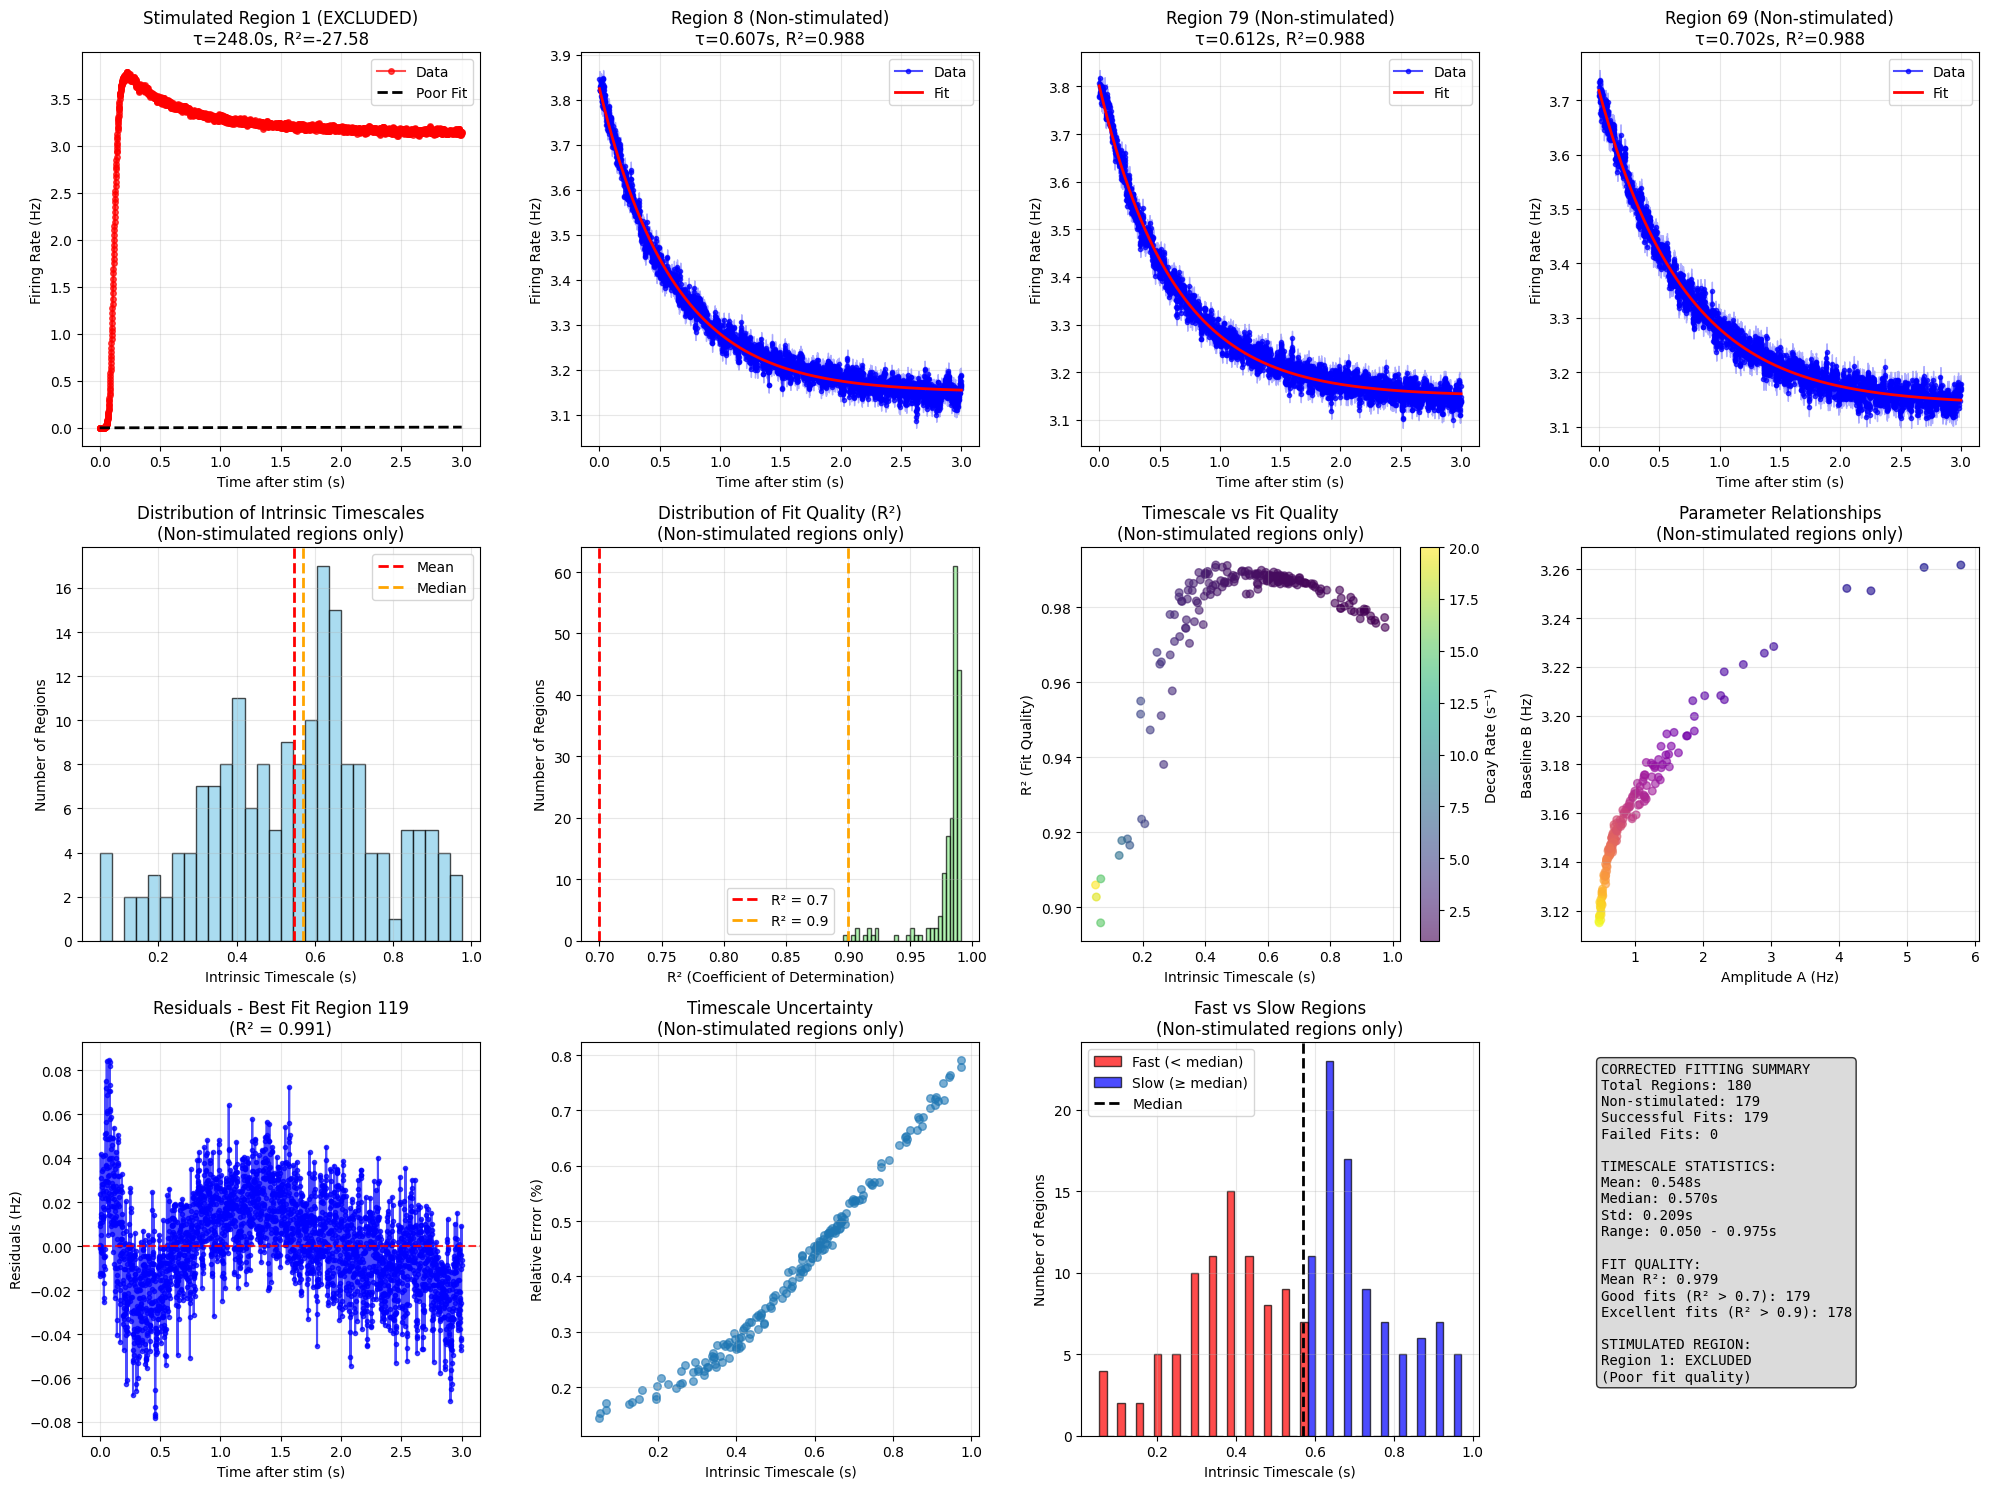


COMPARISON OF ORIGINAL vs CORRECTED RESULTS:
Metric                         Original (All)  Corrected (Non-stim)
-----------------------------------------------------------------


ValueError: Invalid format specifier

In [26]:
# Corrected Visualization: Exclude stimulated region from main plots
print("=== CORRECTED VISUALIZATION (EXCLUDING STIMULATED REGION) ===")

import matplotlib.pyplot as plt
import numpy as np

if corrected_summary['n_successful_non_stim'] > 0:
    # Create comprehensive figure
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Stimulated region (shown separately for reference)
    ax1 = plt.subplot(3, 4, 1)
    stim_idx = decay_data['stimulated_region']
    if fitting_results[stim_idx]['success']:
        result = fitting_results[stim_idx]
        ax1.plot(t_fit, decay_data['r_E_decay'][stim_idx, :], 'ro-', markersize=4, alpha=0.7, label='Data')
        ax1.plot(t_fit, result['fitted_values'], 'k--', linewidth=2, label='Poor Fit')
        ax1.fill_between(t_fit, 
                        decay_data['r_E_decay'][stim_idx, :] - decay_data['sem_decay'][stim_idx, :],
                        decay_data['r_E_decay'][stim_idx, :] + decay_data['sem_decay'][stim_idx, :],
                        alpha=0.3, color='red')
        ax1.set_title(f'Stimulated Region {stim_idx} (EXCLUDED)\nτ={result["timescale"]:.1f}s, R²={result["r_squared"]:.2f}')
    else:
        ax1.text(0.5, 0.5, 'Fit Failed', transform=ax1.transAxes, ha='center', va='center', color='red')
        ax1.set_title(f'Stimulated Region {stim_idx} - FAILED (EXCLUDED)')
    ax1.set_xlabel('Time after stim (s)')
    ax1.set_ylabel('Firing Rate (Hz)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2-4. Sample successful fits from NON-STIMULATED regions
    non_stim_successful = [i for i in corrected_summary['non_stim_indices'] if fitting_results[i]['success']]
    sample_indices = np.random.choice(non_stim_successful, min(3, len(non_stim_successful)), replace=False)
    
    for i, idx in enumerate(sample_indices):
        ax = plt.subplot(3, 4, 2 + i)
        result = fitting_results[idx]
        ax.plot(t_fit, decay_data['r_E_decay'][idx, :], 'bo-', markersize=3, alpha=0.7, label='Data')
        ax.plot(t_fit, result['fitted_values'], 'r-', linewidth=2, label='Fit')
        ax.fill_between(t_fit,
                       decay_data['r_E_decay'][idx, :] - decay_data['sem_decay'][idx, :],
                       decay_data['r_E_decay'][idx, :] + decay_data['sem_decay'][idx, :],
                       alpha=0.3, color='blue')
        ax.set_title(f'Region {idx} (Non-stimulated)\nτ={result["timescale"]:.3f}s, R²={result["r_squared"]:.3f}')
        ax.set_xlabel('Time after stim (s)')
        ax.set_ylabel('Firing Rate (Hz)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 5. Distribution of intrinsic timescales (NON-STIMULATED ONLY)
    ax5 = plt.subplot(3, 4, 5)
    ax5.hist(corrected_summary['timescales'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax5.axvline(np.mean(corrected_summary['timescales']), color='red', linestyle='--', linewidth=2, label='Mean')
    ax5.axvline(np.median(corrected_summary['timescales']), color='orange', linestyle='--', linewidth=2, label='Median')
    ax5.set_xlabel('Intrinsic Timescale (s)')
    ax5.set_ylabel('Number of Regions')
    ax5.set_title('Distribution of Intrinsic Timescales\n(Non-stimulated regions only)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Distribution of R² values (NON-STIMULATED ONLY)
    ax6 = plt.subplot(3, 4, 6)
    ax6.hist(corrected_summary['r_squared_values'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    ax6.axvline(0.7, color='red', linestyle='--', linewidth=2, label='R² = 0.7')
    ax6.axvline(0.9, color='orange', linestyle='--', linewidth=2, label='R² = 0.9')
    ax6.set_xlabel('R² (Coefficient of Determination)')
    ax6.set_ylabel('Number of Regions')
    ax6.set_title('Distribution of Fit Quality (R²)\n(Non-stimulated regions only)')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 7. Timescale vs Fit Quality (NON-STIMULATED ONLY)
    ax7 = plt.subplot(3, 4, 7)
    scatter = ax7.scatter(corrected_summary['timescales'], corrected_summary['r_squared_values'], 
                         c=corrected_summary['decay_rates'], cmap='viridis', alpha=0.6, s=30)
    ax7.set_xlabel('Intrinsic Timescale (s)')
    ax7.set_ylabel('R² (Fit Quality)')
    ax7.set_title('Timescale vs Fit Quality\n(Non-stimulated regions only)')
    ax7.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax7, label='Decay Rate (s⁻¹)')
    
    # 8. Parameter correlations (NON-STIMULATED ONLY)
    ax8 = plt.subplot(3, 4, 8)
    ax8.scatter(corrected_summary['amplitudes'], corrected_summary['baselines'], 
               c=corrected_summary['timescales'], cmap='plasma', alpha=0.6, s=30)
    ax8.set_xlabel('Amplitude A (Hz)')
    ax8.set_ylabel('Baseline B (Hz)')
    ax8.set_title('Parameter Relationships\n(Non-stimulated regions only)')
    ax8.grid(True, alpha=0.3)
    
    # 9. Residual analysis for best non-stimulated region
    ax9 = plt.subplot(3, 4, 9)
    best_non_stim_idx_local = np.argmax(corrected_summary['r_squared_values'])
    best_non_stim_region = corrected_summary['non_stim_indices'][best_non_stim_idx_local]
    best_result = fitting_results[best_non_stim_region]
    
    residuals = best_result['residuals']
    ax9.plot(t_fit, residuals, 'bo-', markersize=3, alpha=0.7)
    ax9.axhline(0, color='red', linestyle='--', alpha=0.8)
    ax9.set_xlabel('Time after stim (s)')
    ax9.set_ylabel('Residuals (Hz)')
    ax9.set_title(f'Residuals - Best Fit Region {best_non_stim_region}\n(R² = {best_result["r_squared"]:.3f})')
    ax9.grid(True, alpha=0.3)
    
    # 10. Timescale uncertainty analysis (NON-STIMULATED ONLY)
    ax10 = plt.subplot(3, 4, 10)
    relative_errors = corrected_summary['timescale_errors'] / corrected_summary['timescales'] * 100
    ax10.scatter(corrected_summary['timescales'], relative_errors, alpha=0.6, s=30)
    ax10.set_xlabel('Intrinsic Timescale (s)')
    ax10.set_ylabel('Relative Error (%)')
    ax10.set_title('Timescale Uncertainty\n(Non-stimulated regions only)')
    ax10.grid(True, alpha=0.3)
    
    # 11. Fast vs Slow regions (NON-STIMULATED ONLY)
    ax11 = plt.subplot(3, 4, 11)
    tau_median = np.median(corrected_summary['timescales'])
    fast_mask = corrected_summary['timescales'] < tau_median
    slow_mask = corrected_summary['timescales'] >= tau_median
    
    ax11.hist([corrected_summary['timescales'][fast_mask], corrected_summary['timescales'][slow_mask]], 
             bins=20, alpha=0.7, label=['Fast (< median)', 'Slow (≥ median)'], 
             color=['red', 'blue'], edgecolor='black')
    ax11.axvline(tau_median, color='black', linestyle='--', linewidth=2, label='Median')
    ax11.set_xlabel('Intrinsic Timescale (s)')
    ax11.set_ylabel('Number of Regions')
    ax11.set_title('Fast vs Slow Regions\n(Non-stimulated regions only)')
    ax11.legend()
    ax11.grid(True, alpha=0.3)
    
    # 12. Corrected summary statistics
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')
    
    # Create corrected summary text
    summary_text = "CORRECTED FITTING SUMMARY\n"
    summary_text += f"Total Regions: {n_regions}\n"
    summary_text += f"Non-stimulated: {corrected_summary['n_successful_non_stim'] + corrected_summary['n_failed_non_stim']}\n"
    summary_text += f"Successful Fits: {corrected_summary['n_successful_non_stim']}\n"
    summary_text += f"Failed Fits: {corrected_summary['n_failed_non_stim']}\n\n"
    summary_text += "TIMESCALE STATISTICS:\n"
    summary_text += f"Mean: {corrected_summary['timescales'].mean():.3f}s\n"
    summary_text += f"Median: {np.median(corrected_summary['timescales']):.3f}s\n"
    summary_text += f"Std: {corrected_summary['timescales'].std():.3f}s\n"
    summary_text += f"Range: {corrected_summary['timescales'].min():.3f} - {corrected_summary['timescales'].max():.3f}s\n\n"
    summary_text += "FIT QUALITY:\n"
    summary_text += f"Mean R²: {corrected_summary['r_squared_values'].mean():.3f}\n"
    summary_text += f"Good fits (R² > 0.7): {np.sum(corrected_summary['r_squared_values'] > 0.7)}\n"
    summary_text += f"Excellent fits (R² > 0.9): {np.sum(corrected_summary['r_squared_values'] > 0.9)}\n\n"
    summary_text += "STIMULATED REGION:\n"
    summary_text += f"Region {stim_idx}: EXCLUDED\n"
    summary_text += "(Poor fit quality)"
    
    ax12.text(0.05, 0.95, summary_text, transform=ax12.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Comparison with original (distorted) results
    print(f"\nCOMPARISON OF ORIGINAL vs CORRECTED RESULTS:")
    print(f"{'Metric':<30} {'Original (All)':<15} {'Corrected (Non-stim)':<20}")
    print(f"{'-'*65}")
    print(f"{'Mean timescale (s)':<30} {fit_summary['timescales'].mean():.3f:<15} {corrected_summary['timescales'].mean():.3f:<20}")
    print(f"{'Std timescale (s)':<30} {fit_summary['timescales'].std():.3f:<15} {corrected_summary['timescales'].std():.3f:<20}")
    print(f"{'Mean R²':<30} {fit_summary['r_squared_values'].mean():.3f:<15} {corrected_summary['r_squared_values'].mean():.3f:<20}")
    print(f"{'Min R²':<30} {fit_summary['r_squared_values'].min():.3f:<15} {corrected_summary['r_squared_values'].min():.3f:<20}")
    print(f"{'Max timescale (s)':<30} {fit_summary['timescales'].max():.1f:<15} {corrected_summary['timescales'].max():.3f:<20}")
    
    print(f"\n→ The corrected analysis excludes the poorly-fitting stimulated region")
    print(f"→ This provides much more realistic and interpretable timescale distributions")

else:
    print("Error: No successful fits for non-stimulated regions to visualize.")

print(f"\n✓ Corrected visualization completed!")


In [27]:
corrected_summary

{'n_total': 180,
 'n_successful_all': 180,
 'n_failed_all': 0,
 'n_successful_non_stim': 179,
 'n_failed_non_stim': 0,
 'timescales': array([0.40370845, 0.38471416, 0.40034451, 0.34576215, 0.28788095,
        0.31690781, 0.63143798, 0.60664262, 0.56692509, 0.61333647,
        0.59898878, 0.32469622, 0.76494334, 0.5186564 , 0.3263192 ,
        0.34340942, 0.26022379, 0.30232106, 0.19421522, 0.19384673,
        0.24624349, 0.05      , 0.53859142, 0.45468911, 0.70070215,
        0.71351901, 0.35016902, 0.58718853, 0.74710244, 0.58011955,
        0.87708287, 0.75207769, 0.86063447, 0.84511557, 0.67030825,
        0.72403761, 0.83436338, 0.62626519, 0.78908903, 0.83279317,
        0.5410488 , 0.77003526, 0.63600823, 0.56963139, 0.46198707,
        0.49760171, 0.45004691, 0.47444835, 0.39727571, 0.59335756,
        0.56309895, 0.6139471 , 0.598115  , 0.66699965, 0.61157717,
        0.89608164, 0.90837771, 0.931192  , 0.91524   , 0.94274095,
        0.91003219, 0.8350849 , 0.97540396, 0.94607